In [1]:
import os
import pandas as pd
import numpy as np
import re

In [2]:


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _norm_text(s):
    if pd.isna(s): 
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def _pick_org(row):
    # Prioriza "Representa a"; si está vacío, usa "Trabaja para"
    rep = row.get("Representa a", "")
    tra = row.get("Trabaja para", "")
    return rep if (isinstance(rep, str) and rep.strip()) else (tra if isinstance(tra, str) else "")

# ------------------------------------------------------------
# Build datasets for LightGCN (1.7.1 "puro")
# ------------------------------------------------------------
def build_lightgcn_inputs(active, aud, passive):
    import pandas as pd, numpy as np, re

    def _norm_text(s):
        if pd.isna(s): 
            return ""
        s = str(s).strip().lower()
        s = re.sub(r"\s+", " ", s)
        return s

    def _pick_org(row):
        rep = row.get("Representa a", "")
        tra = row.get("Trabaja para", "")
        return rep if (isinstance(rep, str) and rep.strip()) else (tra if isinstance(tra, str) else "")

    # --- Copias de trabajo
    active = active.copy()
    aud = aud.copy()
    passive = passive.copy()

    # --- Displays y llave de usuario estable
    active["display_name"] = active["Nombre completo"].fillna("").astype(str).str.strip()
    active["display_org"]  = active.apply(_pick_org, axis=1).astype(str).str.strip()
    active["__name_norm"]  = active["display_name"].map(_norm_text)
    active["__org_norm"]   = active["display_org"].map(_norm_text)
    active["user_key"]     = (active["__name_norm"] + " | " + active["__org_norm"]).str.strip(" |")

    # --- Timestamp desde aud
    aud["timestamp"] = pd.to_datetime(aud["fecha"], errors="coerce")

    # --- Merge con sufijos controlados para evitar choques con columns de active
    aud_cols = ["audiencia_id", "sujeto_pasivo_id", "institucion_id", "timestamp"]
    edges = active.merge(aud[aud_cols], on="audiencia_id", how="inner", suffixes=("_act", "_aud"))

    # --- Tomar SIEMPRE las columnas que vienen de aud (las que nos interesan)
    # sujeto_pasivo_id puede haberse llamado 'sujeto_pasivo_id_aud' tras el merge
    sp_col  = "sujeto_pasivo_id_aud" if "sujeto_pasivo_id_aud" in edges.columns else "sujeto_pasivo_id"
    inst_col= "institucion_id_aud"   if "institucion_id_aud"   in edges.columns else "institucion_id"

    # --- Crear llaves limpias
    edges["item_key"]       = edges[sp_col].astype(str).str.strip()
    edges["institution_id"] = edges[inst_col].astype(str).str.strip()
    edges["timestamp"] = pd.to_datetime(edges["timestamp"], errors="coerce")
    # --- Filtrar nulos básicos
    edges = edges.dropna(subset=["user_key","item_key","timestamp"])

    # --- Dedup por día (opcional)
    edges["__date"] = edges["timestamp"].dt.date
    edges = edges.drop_duplicates(subset=["user_key","item_key","__date"]).drop(columns="__date")

    # --- Indexación determinista (0-based) para estabilidad
    user_index = (pd.DataFrame({"user_key": sorted(edges["user_key"].unique())})
                    .reset_index().rename(columns={"index":"user_id"}))
    item_index = (pd.DataFrame({"item_key": sorted(edges["item_key"].unique())})
                    .reset_index().rename(columns={"index":"item_id"}))

    edges = (edges.merge(user_index, on="user_key", how="left")
                  .merge(item_index, on="item_key", how="left"))

    # --- Catálogos
    users_df = (user_index
                .merge(active[["user_key","display_name","display_org"]].drop_duplicates("user_key"),
                       on="user_key", how="left"))

    passive = passive.rename(columns={"id":"item_key"})
    passive["item_key"] = passive["item_key"].astype(str).str.strip()
    items_df = (item_index
                .merge(passive[["item_key","nombre","cargo","institution_id"]],
                       on="item_key", how="left"))

    # --- Interacciones finales
    interactions_df = edges[["user_id","item_id","timestamp"]].sort_values(["user_id","timestamp"]).reset_index(drop=True)

    return interactions_df, users_df, items_df


In [3]:
active = pd.read_csv(os.path.join("data", "active_subjects.csv"))
aud    = pd.read_csv(os.path.join("data", "audiencies.csv"))
inst   = pd.read_csv(os.path.join("data", "institutions.csv"))
passive= pd.read_csv(os.path.join("data", "passive_subjects.csv"))
interactions_df, users_df, items_df = build_lightgcn_inputs(active, aud, passive)

/var/folders/pc/1tbslm8954q5q5cyk947n34h0000gn/T/ipykernel_8797/4053659012.py:48: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  aud["timestamp"] = pd.to_datetime(aud["fecha"], errors="coerce")


In [4]:
from src.state_of_art_models.lightGCN_base import LightGCNRunner

In [5]:
runner = LightGCNRunner(
    dim=64, n_layers=3, lr=1e-3, l2=1e-4,
    batch_size=4096, epochs=300, patience=20
)

test_metrics = runner.fit(interactions_df)
print(test_metrics)

/Users/camilarojasguajardo/Desktop/Magister/lobby-recsys/src/state_of_art_models/lightGCN_base.py:85: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:55.)
  A_hat = torch.sparse.mm(torch.sparse.mm(D_inv_sqrt, A), D_inv_sqrt).coalesce()


Epoch 001 | loss 0.6891 | val nDCG@10 0.0324
Epoch 002 | loss 0.6538 | val nDCG@10 0.0340
Epoch 003 | loss 0.5781 | val nDCG@10 0.0340
Epoch 004 | loss 0.4849 | val nDCG@10 0.0343
Epoch 005 | loss 0.3940 | val nDCG@10 0.0342
Epoch 006 | loss 0.3170 | val nDCG@10 0.0343
Epoch 007 | loss 0.2551 | val nDCG@10 0.0345
Epoch 008 | loss 0.2099 | val nDCG@10 0.0345
Epoch 009 | loss 0.1745 | val nDCG@10 0.0346
Epoch 010 | loss 0.1473 | val nDCG@10 0.0346
Epoch 011 | loss 0.1273 | val nDCG@10 0.0347
Epoch 012 | loss 0.1104 | val nDCG@10 0.0348
Epoch 013 | loss 0.0962 | val nDCG@10 0.0350
Epoch 014 | loss 0.0857 | val nDCG@10 0.0351
Epoch 015 | loss 0.0767 | val nDCG@10 0.0352
Epoch 016 | loss 0.0690 | val nDCG@10 0.0354
Epoch 017 | loss 0.0625 | val nDCG@10 0.0356
Epoch 018 | loss 0.0574 | val nDCG@10 0.0357
Epoch 019 | loss 0.0524 | val nDCG@10 0.0358
Epoch 020 | loss 0.0493 | val nDCG@10 0.0359
Epoch 021 | loss 0.0464 | val nDCG@10 0.0360
Epoch 022 | loss 0.0422 | val nDCG@10 0.0362
Epoch 023 

   epoch    loss  val_ndcg10
0      1  0.6891      0.0324
1      2  0.6538      0.0340
2      3  0.5781      0.0340
3      4  0.4849      0.0343
4      5  0.3940      0.0342


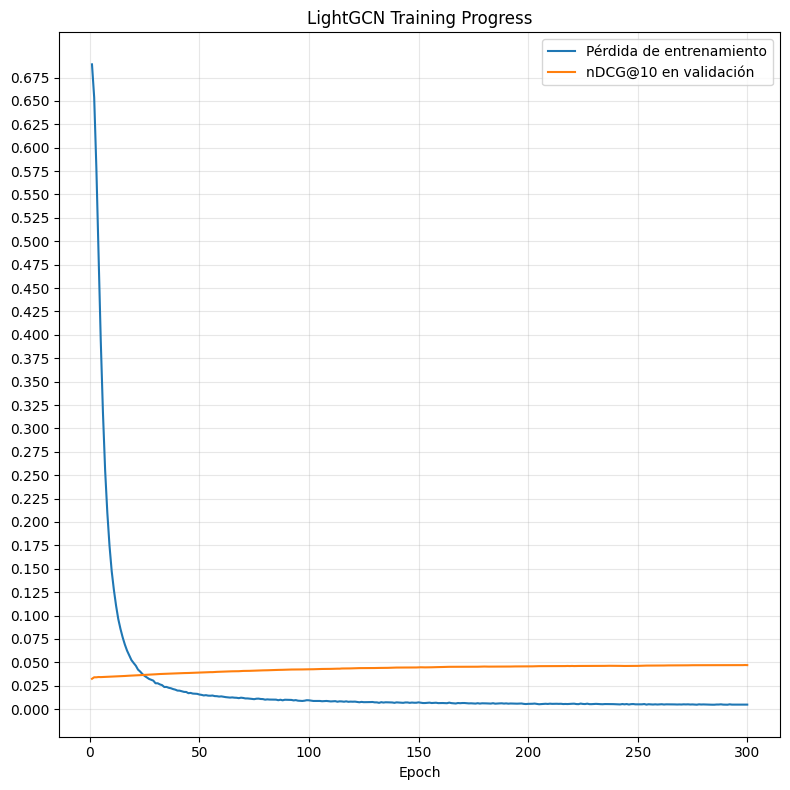

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Leer CSV ---
# (ajusta la ruta si lo guardaste en otro lugar)
df = pd.read_csv("output/lightGCN/training_log/30-10-2025.csv")

# Vista rápida de los primeros registros
print(df.head())

# --- 2. Graficar métricas de entrenamiento ---
plt.figure(figsize=(8, 8))
plt.plot(df["epoch"], df["loss"], label="Pérdida de entrenamiento", color="tab:blue")
plt.plot(df["epoch"], df["val_ndcg10"], label="nDCG@10 en validación", color="tab:orange")
ymin = 0
ymax = max(df["loss"].max(), df["val_ndcg10"].max()) + 0.01
plt.yticks(np.arange(ymin, ymax, 0.025))
plt.title("LightGCN Training Progress")
plt.xlabel("Epoch")
plt.ylabel("")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import pandas as pd

def recommend_all_topk(runner, topk=10, batch_users=2048):
    device = runner.device
    assert runner.model is not None, "Entrena el modelo primero."

    runner.model.eval()
    with torch.no_grad():
        users_f, items_f = runner.model.propagate()
        users_f = users_f.to(device)
        items_f = items_f.to(device)

    rows = []
    for start in range(0, runner.n_users, batch_users):
        end = min(start + batch_users, runner.n_users)
        U = users_f[start:end]                      # [B, d]
        scores = U @ items_f.T                      # [B, n_items]

        for local_idx, u in enumerate(range(start, end)):
            seen = runner.tr_ui.get(u, set())
            if seen:
                seen_idx = torch.tensor(list(seen), device=device, dtype=torch.long)
                scores[local_idx, seen_idx] = -1e9

        vals, idxs = torch.topk(scores, k=topk, dim=1)   # [B, topk]
        vals = vals.detach().cpu()
        idxs = idxs.detach().cpu()

        for i, u in enumerate(range(start, end)):
            for r in range(topk):
                rows.append({
                    "user_id": u,
                    "rank": r + 1,
                    "item_id": int(idxs[i, r]),
                    "score": float(vals[i, r]),
                })

    return pd.DataFrame(rows)

# Uso:
top10_df = recommend_all_topk(runner, topk=10, batch_users=2048)
top10_df.to_csv("output/lightGCN/recommendations_top10/30-10-2025.csv", index=False)


In [29]:
import pandas as pd
import numpy as np


def recall_at_k_per_user(topk_df, te_ui, k=10):
    recalls = []
    for u, group in topk_df.groupby("user_id"):
        recommended = set(group[group["rank"] <= k]["item_id"])
        relevant = te_ui.get(u, set())
        if not relevant:
            continue
        hits = len(recommended & relevant)
        recall = hits / len(relevant)
        recalls.append({"user_id": u, "recall@10": recall, "hits": hits, "relevant": len(relevant)})
    return pd.DataFrame(recalls)

recall_df = recall_at_k_per_user(top10_df, runner.te_ui, k=10)


worst5 = recall_df.nsmallest(5, "recall@10")
best5  = recall_df.nlargest(5, "recall@10")

print("=== 5 usuarios con PEOR Recall@10 ===")
print(worst5)

print("\n=== 5 usuarios con MEJOR Recall@10 ===")
print(best5)


=== 5 usuarios con PEOR Recall@10 ===
   user_id  recall@10  hits  relevant
0        0        0.0     0         1
1        1        0.0     0         1
2        2        0.0     0         1
3        3        0.0     0         1
4        4        0.0     0         1

=== 5 usuarios con MEJOR Recall@10 ===
     user_id  recall@10  hits  relevant
22        22        1.0     1         1
156      156        1.0     1         1
217      217        1.0     1         1
226      226        1.0     1         1
271      271        1.0     1         1


In [ ]:
import torch
import json
import os

save_dir = "output/lightGCN/models"
os.makedirs(save_dir, exist_ok=True)

# --- 1. Guarda los pesos del modelo ---
torch.save(runner.model.state_dict(), f"{save_dir}/lightgcn_weights.pt")

# --- 2. Guarda la configuración y metadatos (opcional pero muy útil) ---
config = {
    "n_users": runner.n_users,
    "n_items": runner.n_items,
    "dim": runner.dim,
    "n_layers": runner.n_layers,
    "device": runner.device,
}
with open(f"{save_dir}/lightgcn_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("✅ Modelo y configuración guardados en", save_dir)


✅ Modelo y configuración guardados en output/lightGCN/models


In [35]:
import torch
import json
from src.state_of_art_models.lightGCN_base import LightGCN

# --- 1. Carga la configuración ---
with open("output/lightGCN/models/lightgcn_config.json") as f:
    cfg = json.load(f)

# --- 2. Reconstruye el modelo ---
# A_hat no es necesario para inferencia (solo si quieres seguir entrenando)
dummy_A_hat = torch.sparse_coo_tensor(
    torch.zeros((2, 0), dtype=torch.long), torch.zeros(0), size=(cfg["n_users"] + cfg["n_items"], cfg["n_users"] + cfg["n_items"])
).coalesce()

model = LightGCN(
    n_users=cfg["n_users"],
    n_items=cfg["n_items"],
    dim=cfg["dim"],
    n_layers=cfg["n_layers"],
    A_hat=dummy_A_hat,
)

# --- 3. Carga los pesos ---
model.load_state_dict(torch.load("output/lightGCN/models/lightgcn_weights.pt", map_location=cfg["device"]))
model.eval()
print("✅ Modelo cargado correctamente")

# Ejemplo de uso (usando tu runner para consistencia)
runner.model = model.to(cfg["device"])


✅ Modelo cargado correctamente


In [34]:
# Propaga embeddings
users_f, items_f = model.propagate()

# Escoge un usuario
u = 42  # por ejemplo
scores = (users_f[u] * items_f).sum(dim=1)

# (opcional) enmascara ítems vistos
seen = runner.tr_ui.get(u, set()) if hasattr(runner, "tr_ui") else set()
if seen:
    scores[list(seen)] = -1e9

# Obtén los top-10 ítems más recomendados
top_items = torch.topk(scores, 10).indices.cpu().tolist()
print("Recomendaciones para usuario", u, ":", top_items)


Recomendaciones para usuario 42 : [1192, 5022, 2587, 9879, 10942, 10412, 260, 16610, 3647, 6035]
